# EI Tuning — Wilson-Cowan Whole-Brain Model

각 셀은 독립적인 파트를 담당한다. **파라미터 수정은 Cell 2에서만 한다.**

In [1]:
# JAX 메모리 설정: import 전에 반드시 실행해야 한다
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")

import jax
jax.config.update("jax_enable_x64", False)

print(f"backend : {jax.default_backend()}")
print(f"devices : {jax.devices()}")
print(f"jax_enable_x64 : {jax.config.jax_enable_x64}")

from config              import Config
from data_loader         import load_data
from model               import build_network
from part1_fic           import run_fic
from part2_eib           import run_eib
from part3_gradient      import run_gradient_optimization
from part4_dbs           import run_dbs_stimulation
from pipeline_contracts  import ParamSet, StateBundle, capture_internal_state, capture_network_delay_history


backend : gpu
devices : [CudaDevice(id=0)]
jax_enable_x64 : False


## Cell 2 — Config

**파라미터 수정은 이 셀에서만 한다.**

## Dataset 선택

`dataset = "mouse"` 또는 `"human"` 으로 설정하면
Wilson-Cowan 파라미터와 FIC 설정, 데이터 파일이 자동으로 전환된다.

In [2]:
# ── Dataset 고정 (pd: CHA-22 mouse) ───────────────
dataset = "pd"

_DATASET_PARAMS = {
    "pd": dict(
        # RWW 모델 사용 — WC 파라미터는 Config 요구사항으로 유지(모델 미참조). mouse 값 차용.
        wc_c_ei_init=10.0,
        fic_target_firing_rate_hz=2.0,   # 진단용 Hz 표시 (FIC 제어는 fic_target_se=S_e gating)
        # DBS: CHA-22 익명 atlas — STN 없음 → 타깃 없음(아래 DBS 셀에서 skip)
        dbs_target_regions={},
        bold_hrf_k1=5.6,
        bold_hrf_V0=0.02,
        bold_hrf_tau_s=0.8,
        bold_hrf_tau_f=0.4,
        bold_hrf_scaling=1.0 / 3.0,
        bold_hrf_duration_ms=32_000.0,
        sc_csv="pd/sub-419077_mouse_CHA_weight.csv",
        length_csv="pd/sub-419077_mouse_CHA_tract_length.csv",
        fc_csv="pd/sub-419077_ses-1_task-rest_bold_RAS_resampled_cleaned_FC_matrix.csv",
        region_txt="pd/mouse_CHA.txt",
        tract_conduction_speed=3.0,
        additive_noise_sigma=0.02,
    ),
}

_p = _DATASET_PARAMS[dataset]
print(f'Dataset: {dataset}  (CHA-22 mouse)')
print(f'  sc_csv={_p["sc_csv"]}')
print(f'  region_txt={_p["region_txt"]}')


Dataset: pd  (CHA-22 mouse)
  sc_csv=pd/sub-419077_mouse_CHA_weight.csv
  region_txt=pd/mouse_CHA.txt


In [3]:
cfg = Config(
    # ── 데이터 경로 ──────────────────────────────────────────
    region_txt                          = _p["region_txt"],
    sc_csv                              = _p["sc_csv"],
    length_csv                          = _p["length_csv"],
    fc_csv                              = _p["fc_csv"],
    cache_version                       = "v_cha22_p33segating_pd",
    cache_run_label                     = "pd_cha22",

    # ── 시뮬레이션 공통 ──────────────────────────────────────
    integration_dt_ms                   = 1.0,
    warmup_duration_ms                  = 720_000,
    # -- Patch 13: Bold HRF parameters -------------------
    bold_hrf_k1          = _p["bold_hrf_k1"],
    bold_hrf_V0          = _p["bold_hrf_V0"],
    bold_hrf_tau_s       = _p["bold_hrf_tau_s"],
    bold_hrf_tau_f       = _p["bold_hrf_tau_f"],
    bold_hrf_scaling     = _p["bold_hrf_scaling"],
    bold_hrf_duration_ms = _p["bold_hrf_duration_ms"],

    bold_repetition_time_ms             = 1000.0,
    tract_conduction_speed              = _p["tract_conduction_speed"],
    additive_noise_sigma                = _p["additive_noise_sigma"],

    # ── Part 1 — FIC (구버전 notebook 로직) ─────────────────
    fic_target_firing_rate_hz           = _p["fic_target_firing_rate_hz"],
    fic_learning_rate                   = 1e-3,
    fic_max_iterations                  = 2000,
    fic_early_stop_patience             = 500,
    fic_early_stop_tolerance_hz         = 0.10,
    fic_step_duration_ms                = 1_000,
    fic_step_skip_tr                    = 0,
    freeze_c_ei_after_fic               = False,   # True: Part2(EIB)에서만 c_ei 동결. Part3는 항상 c_ei 최적화

    # ── Part 2 — EIB (구버전 notebook 로직) ─────────────────
    eib_max_iterations                  = 8000,
    eib_internal_fic_learning_rate      = 0.05,
    eib_max_weight_learning_rate        = 0.002,
    eib_bold_window_samples             = 720,
    eib_snapshot_save_interval          = 50,
    connectivity_weight_max             = 1.5,

    eib_posthoc_duration_ms             = 720_000,
    eib_posthoc_skip_tr                 = 60,

    # ── Part 3 — Full Gradient (구버전 notebook 로직) ───────
    optimizer_learning_rate             = 0.0005,
    optimizer_max_steps                 = 1000,
    optimizer_chunk_steps               = 10,
    optimizer_bold_window_tr            = 720,
    optimizer_bold_skip_tr              = 60,


    # ── Phase 1 final baseline settle ────────────────────────
    baseline_settle_duration_ms         = 0,

    # ── EIB score 계산용 ──────────────────────────────────────
    pd_fit_region_count                 = 14,
    full_brain_fc_loss_weight           = 1.00,
    pd_fit_block_loss_weight            = 0.00,
    correlation_loss_weight             = 0.80,   # EIB scoring (keep)
    rmse_loss_weight                    = 0.20,   # EIB scoring (keep)

    # ── Patch 9: Gradient 3-term loss weights ────────────────
    optimizer_global_corr_weight        = 0.40,   # alpha: global FC corr
    optimizer_nodewise_corr_weight      = 0.40,   # beta:  node-wise FC corr
    optimizer_rmse_weight               = 0.20,   # gamma: global FC RMSE

    # ── Part 4 — DBS ─────────────────────────────────────────
    # DBS target regions (dataset-specific)
    dbs_target_regions               = _p["dbs_target_regions"],

    dbs_pulse_amplitude                 = 10.0,
    dbs_stimulation_frequency_hz        = 130.0,
    dbs_phase_duration_steps            = 1,
    dbs_pre_stimulation_duration_ms     = 60_000.0,
    dbs_stimulation_duration_ms         = 60_000.0,

    wc_c_ei_init = _p["wc_c_ei_init"],
)
cfg.print_summary()

  Config
  region_txt                                   = pd/mouse_CHA.txt
  sc_csv                                       = pd/sub-419077_mouse_CHA_weight.csv
  length_csv                                   = pd/sub-419077_mouse_CHA_tract_length.csv
  fc_csv                                       = pd/sub-419077_ses-1_task-rest_bold_RAS_resampled_cleaned_FC_matrix.csv
  cache_root_dir                               = ./cache
  cache_run_label                              = pd_cha22
  param_save_dir                               = ./optimized_params
  cache_version                                = v_cha22_p33segating_pd
  wc_c_ee                                      = 11.0
  wc_c_ei                                      = 10.0
  wc_c_ie                                      = 10.0
  wc_c_ii                                      = 1.0
  wc_r_e                                       = 1.0
  wc_r_i                                       = 1.0
  wc_tau_e                                     = 10.0
 

## Cell 3 — Data Loading

SC / tract_length / FC 로드 및 전처리. weights/delays/fc_target 행렬을 시각화한다.

Cache stored here: /scratch/home/wog3597/optim/cache/pd_cha22/v_cha22_p33segating_pd_N22_sce0276885c2_fcb4438fc1e2
[DATA] n_nodes=22  SC nonzero=340
[DATA] weights:   min=0.0000e+00  max=1.0000e+00
[DATA] fc_target: min=-6.6037e-01  max=6.9115e-01
[DATA] delays:    min=0.00ms  max=4.40ms  (speed=3.0 mm/ms)
[DATA] SC mask:   340 / 484  (70.2%)
[DATA] cache_tag = v_cha22_p33segating_pd_N22_sce0276885c2_fcb4438fc1e2
[DATA] Graph type: DenseDelayGraph


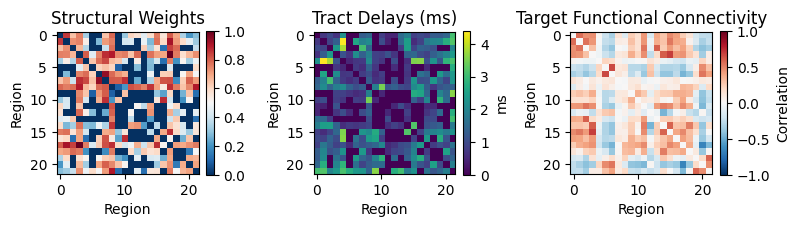

In [4]:
data = load_data(cfg)


## Cell 4 — Build Network & Warmup

In [5]:
network, initial_state, bold_monitor, warmup_result = build_network(cfg, data)

initial_params = ParamSet.default(data["n_nodes"], c_ei_init=cfg.wc_c_ei_init).sanitize(
    data["sc_mask"], cfg.connectivity_weight_max
)

bundle_init = StateBundle.from_warmup(
    warmup_result          = warmup_result,
    bold_monitor_template  = bold_monitor,
    initial_params         = initial_params,
    internal_state         = capture_internal_state(initial_state),
    delay_history          = capture_network_delay_history(network),
    stage                  = "warmup",
)

print(bundle_init)

[MODEL] Running warmup simulation...
[MODEL] Warmup done — E mean=0.0885  I mean=0.1240
[MODEL] Graph type: DenseDelayGraph
StateBundle(stage='warmup', c_ei_frozen=False, init_dyn_shape=(2, 22))


## Pipeline timing diagnostics (read-only, Patch 3)

각 단계의 예상 소요 시간만 표시한다. 시뮬레이션을 실행하지 않으며 캐시를 건드리지 않는다.
JAX backend / device 확인, dispatch latency, 단계별 step×per-step 추정치 합산.

In [6]:
# === Pipeline timing diagnostics (Patch 3) ===
from timing_utils import estimate_stage, print_estimates, print_gpu_summary
import time as _t, jax, jax.numpy as _jnp

print_gpu_summary()

# JAX per-dispatch latency micro-benchmark
_n = data['n_nodes']
_x = _jnp.ones((_n, 2), dtype=_jnp.float32)
_f = jax.jit(lambda x: x * 1.0001 + 0.0001)
_f(_x).block_until_ready()  # warmup
_t0 = _t.perf_counter()
for _ in range(200):
    _x = _f(_x)
_x.block_until_ready()
_jax_latency = (_t.perf_counter() - _t0) / 200
print(f'\nJAX per-dispatch latency ≈ {_jax_latency*1000:.3f} ms (N={_n})')

_tr_ms = cfg.bold_repetition_time_ms
_cost = 0.0008  # GPU 기준 fallback (sim 1ms당 약 0.8ms wall)

# DBS baseline+stim per target: config의 dbs_pre_stimulation_duration_ms + dbs_stimulation_duration_ms
_dbs_pre = getattr(cfg, 'dbs_baseline_duration_ms', None)
if _dbs_pre is None:
    _dbs_pre = getattr(cfg, 'dbs_pre_stimulation_duration_ms', 60_000.0)
_dbs_total_per_target = float(_dbs_pre) + float(cfg.dbs_stimulation_duration_ms)

_estimates = [
    estimate_stage('FIC',
        n_steps=int(cfg.fic_max_iterations),
        fallback_step_sec=cfg.fic_step_duration_ms * _cost),
    estimate_stage('EIB-search',
        n_steps=int(cfg.eib_max_iterations),
        fallback_step_sec=_tr_ms * _cost),
    estimate_stage('EIB-posthoc',
        n_steps=1,
        fallback_step_sec=cfg.eib_posthoc_duration_ms * _cost),
    estimate_stage('Gradient',
        n_steps=int(cfg.optimizer_max_steps),
        fallback_step_sec=cfg.optimizer_bold_window_tr * _tr_ms * _cost),
    estimate_stage('DBS (per target)',
        n_steps=len(cfg.dbs_target_regions),
        fallback_step_sec=_dbs_total_per_target * _cost),
]
print_estimates(_estimates)

print('\n[hint] Patch 3: cfg.posthoc_parallel=True 시 EIB-posthoc ~20-30% 단축.')
print('[hint] cfg.optimizer_chunk_steps=5~10 시 Gradient ~10% 단축 (수렴 dynamics 변경 감수).')
print('[hint] 위 예측은 ±50% 오차. 실측은 각 run_* 의 [STAGE] 라인 참조.')

                        JAX backend / device summary                        
             backend: gpu
        device_count: 1
             devices: ['cuda:0']
      default_device: cuda:0
         x64_enabled: False

JAX per-dispatch latency ≈ 0.040 ms (N=22)
            Pipeline timing estimates (analytical + JAX latency)            
[             FIC] steps=  2000  per-step=  800.00ms  total≈26.7min
[      EIB-search] steps=  8000  per-step=  800.00ms  total≈1.78h
[     EIB-posthoc] steps=     1  per-step=576000.00ms  total≈9.6min
[        Gradient] steps=  1000  per-step=576000.00ms  total≈160.00h
[DBS (per target)] steps=     0  per-step=96000.00ms  total≈0.0s
----------------------------------------------------------------------------
                          TOTAL (excl. caching, compile)  ≈ 162.38h

[hint] Patch 3: cfg.posthoc_parallel=True 시 EIB-posthoc ~20-30% 단축.
[hint] cfg.optimizer_chunk_steps=5~10 시 Gradient ~10% 단축 (수렴 dynamics 변경 감수).
[hint] 위 예측은 ±50% 오차. 실측은 각 run_* 

## Cell 5 — Part 1: FIC

구버전 notebook 로직: **1초 step × 2000** 반복, `c_ei`는 아직 동결하지 않는다.

In [ ]:
# Part 1: FIC — 구버전 notebook 로직 (c_ei는 이후 단계에서도 계속 업데이트)
bundle_fic = run_fic(
    network   = network,
    bundle_in = bundle_init,
    cfg       = cfg,
    data      = data,
)
assert not bundle_fic.params.c_ei_frozen, "Old-logic FIC should keep c_ei unfrozen"
print(f"[FIC] c_ei_frozen={bundle_fic.params.c_ei_frozen}  mean c_ei={bundle_fic.params.c_ei.mean():.4f}")
print(bundle_fic)


Running computations for fic_v_cha22_p33segating_pd_N22_sce0276885c2_fcb4438fc1e2_se0.25_eta0p001_steps2000_dur1000_skip0_bestbundlev4_fpdc8e93b6ac3b
[FIC] target S_e=0.25  eta=0.001  max_steps=2000
  step=1s  skip=0 TR  use=1 TR
  step   25/2000  mean_S_e=0.0999  rE=1.999 Hz  se_err=0.1501  (20.7s)
  step   50/2000  mean_S_e=0.1025  rE=2.049 Hz  se_err=0.1475  (37.0s)
  step   75/2000  mean_S_e=0.1039  rE=2.079 Hz  se_err=0.1461  (53.3s)


## Cell 6 — Part 2: EIB Tuning

구버전 notebook 로직: **150 TR window / 8000 step / EIB 중에도 c_ei 업데이트**.

In [ ]:
# Part 2: EIB — 구버전 notebook 로직 (c_ei + wLRE/wFFI 동시 튜닝)
bundle_eib = run_eib(
    network   = network,
    bundle_in = bundle_fic,
    cfg       = cfg,
    data      = data,
)
assert not bundle_eib.params.c_ei_frozen, "Old-logic EIB should keep c_ei unfrozen"
print(f"[EIB] stage={bundle_eib.stage}  c_ei_frozen={bundle_eib.params.c_ei_frozen}")
print(bundle_eib)


## Cell 7 — Part 3: Full-matrix Gradient Optimization

구버전 notebook 로직: **96 TR / skip 8 / c_ei·wLRE·wFFI 모두 dense 최적화**.

In [ ]:
# Part 3: Full-matrix Gradient Optimization
bundle_grad = run_gradient_optimization(
    network   = network,
    bundle_in = bundle_eib,
    warmup_bundle = bundle_init,
    cfg       = cfg,
    data      = data,
)
print(f"[Part3] stage={bundle_grad.stage}  c_ei_frozen={bundle_grad.params.c_ei_frozen}")
print(bundle_grad)


## Cell 8 — Part 4: DBS Stimulation

Biphasic pulse train 자극 + pre vs during PSD 비교

In [ ]:
# Part 4: DBS — CHA-22 atlas는 STN 표적 매핑 불가 → DBS skip
print("[4] DBS skipped — CHA-22 atlas has no STN target mapping")
# DBS를 켜려면 cfg.dbs_target_regions에 표적 노드(예: BG_Pallidum=19) 지정 후:
#   run_dbs_stimulation(network=network, bundle_in=bundle_grad, cfg=cfg, data=data)


In [ ]:
# Part 4: DBS — CHA-22 atlas는 STN 표적 매핑 불가 → DBS skip
print("[4] DBS skipped — CHA-22 atlas has no STN target mapping")
# DBS를 켜려면 cfg.dbs_target_regions에 표적 노드(예: BG_Pallidum=19) 지정 후:
#   run_dbs_stimulation(network=network, bundle_in=bundle_grad, cfg=cfg, data=data)


In [ ]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path(f"paper_figures_{STAMP}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_first_file(root: Path, filename: str):
    matches = list(root.rglob(filename))
    if not matches:
        return None
    matches.sort(key=lambda p: len(p.parts))
    return matches[0]

# 4개 region 이름
target_labels = list(cfg.dbs_target_regions.keys())[:4]

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

for ax, target_label in zip(axes, target_labels):
    target_dir = Path(cfg.dbs_output_base_dir) / target_label
    psd_csv = find_first_file(target_dir, "psd_pre_vs_during.csv")

    if psd_csv is None:
        ax.set_title(f"{target_label} (PSD file not found)")
        ax.axis("off")
        continue

    df = pd.read_csv(psd_csv)

    freq_col = None
    pre_col = None
    during_col = None

    for c in df.columns:
        cl = c.lower()
        if "freq" in cl:
            freq_col = c
        elif "pre" in cl and "psd" in cl:
            pre_col = c
        elif "during" in cl and "psd" in cl:
            during_col = c

    if freq_col is None or pre_col is None or during_col is None:
        ax.set_title(f"{target_label} (Unexpected PSD CSV format)")
        ax.axis("off")
        continue

    freq = np.asarray(df[freq_col], dtype=np.float32)
    psd_pre = np.asarray(df[pre_col], dtype=np.float32)
    psd_during = np.asarray(df[during_col], dtype=np.float32)

    mask = freq <= 100.0
    freq = freq[mask]
    psd_pre = psd_pre[mask]
    psd_during = psd_during[mask]

    ax.plot(freq, psd_pre, linewidth=1.8, label="Pre")
    ax.plot(freq, psd_during, linewidth=1.8, label="During")
    
    # Y축 로그 스케일 적용
    ax.set_yscale('log')
    
    ax.set_xlim(0, 100)
    ax.set_title(target_label, fontsize=12)
    ax.set_ylabel("PSD (Log Scale)")
    
    # 그리드 설정 (로그 스케일 시 major/minor 그리드 모두 표시하면 가독성이 좋아짐)
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Frequency (Hz)")

fig.tight_layout()

save_png = OUT_DIR / "DBS_PSD_4regions_stacked_log.png"
save_pdf = OUT_DIR / "DBS_PSD_4regions_stacked_log.pdf"

fig.savefig(save_png, dpi=300, bbox_inches="tight")
fig.savefig(save_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {save_png.resolve()}")
print(f"Saved: {save_pdf.resolve()}")